In [1]:
from evoscape.jax.flax_models.landscape_flax import LandscapeFlax
from evoscape.jax.flax_models.autoencoder_flax import AutoEncoder

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx


from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape
from evoscape.jax.experiment import Experiment
from evoscape.jax.dynamics import state_probs
from evoscape.jax.utils import make_movie_landscape, init_cell_circle

plt.style.use("default")

In [2]:
modules = (
    Node(x=1.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
    Node(x=-2.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

Époque 0 | Loss: 0.0878
Époque 10 | Loss: 0.1119
Époque 20 | Loss: 0.0157
Époque 30 | Loss: 0.0200
Époque 40 | Loss: 0.0058
Époque 50 | Loss: 0.0237
Époque 60 | Loss: 0.0097
Époque 70 | Loss: 0.0092
Époque 80 | Loss: 0.0046
Époque 90 | Loss: 0.0030


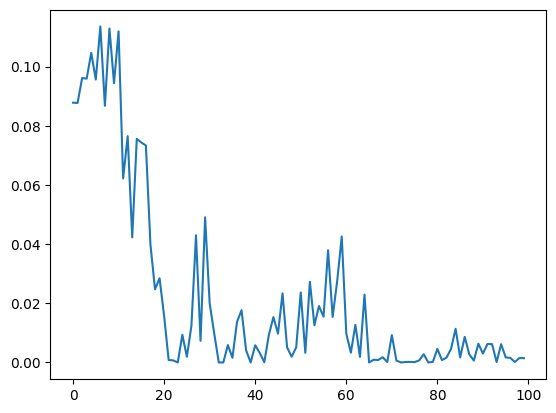

In [3]:

q_init = jnp.zeros((2, 100))  

# Initializing the landscape 
rngs = nnx.Rngs(0)
model = LandscapeFlax(landscape, rngs)

model.set_simulation(init_noise=0.2, t0=0.0, tf=10.0, nt=100, ndt=10, noise=0.2)
model.set_regime_params(signal_param=None)
model.set_state_probs(state_probs)

# Defining the optimizer 

optimizer = nnx.Optimizer(model, optax.adam(1e-2), wrt=nnx.Param)

# Defining the loss function, and the train_step 

def loss_fn(model: LandscapeFlax, q_init):
    # Forward pass
    traj, states = model(q_init)
    
    final_states = jnp.mean(states[:, :, -1], axis=1) # avg over cells

    # using target proportion 75% / 25%
    proportion_loss = jnp.sum((final_states - jnp.array((0.75, 0.25))) ** 2)

    return proportion_loss


@nnx.jit
def train_step(model: LandscapeFlax, optimizer: nnx.Optimizer, q_init):
    # nnx.value_and_grad computes the gradient with respect to the nnx.Params
    loss, grads = nnx.value_and_grad(loss_fn)(model, q_init)
    
    optimizer.update(model, grads)
    
    return loss

# Training loop 
n_epochs = 100
loss_vals = []

for epoch in range(n_epochs):
    loss_val = train_step(model, optimizer, q_init)
    
    if epoch%10 == 0:
        print(f"Époque {epoch} | Loss: {loss_val:.4f}")

    loss_vals.append(loss_val)

plt.plot(loss_vals)

Landscape with modules:
Node: x=1.2756974697113037; y=-0.023895954713225365; a=1.2795756; s=1.1705675,
Node: x=-2.267584800720215; y=0.02832222916185856; a=1.7058153; s=1.2324


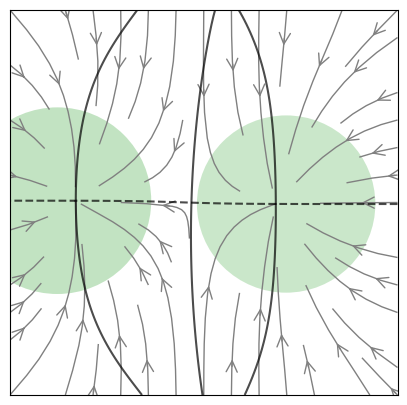

In [4]:
l = model.get_landscape()

print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')


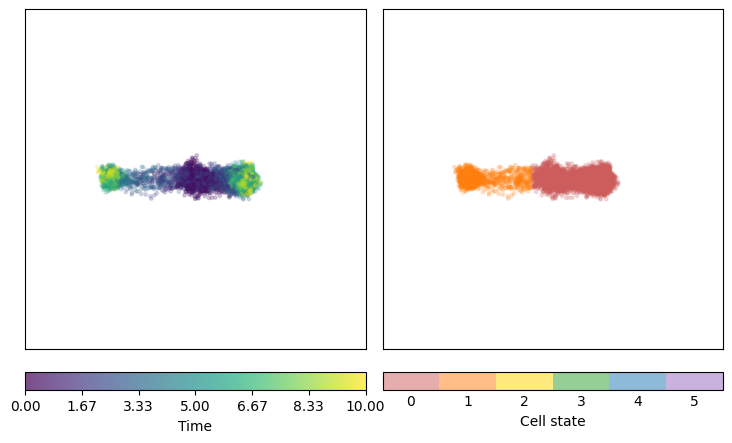

In [5]:
t0=0.0
tf=10.0
nt=100
traj, states = model(q_init)

fig = plot_traj(traj, states, t0, tf, nt, L=4)

### Creating an autoencoder from the landscape

In [6]:
dims_encoder = [5,2]
dims_decoder = [2,4,5]

autoencoder = AutoEncoder(model, dims_decoder=dims_decoder, dims_encoder=dims_encoder, rngs=rngs)

q_init = jnp.zeros((5, 10))  

result = autoencoder(q_init)
print(result.shape)

(5, 10, 100)
